# 計算Si $E_f-E_v$

## 參數設定

* 參考FerroX預設參數
* 使用這個網站估算P++ Si的Na: https://www.pveducation.org/pvcdrom/materials/general-properties-of-silicon 

In [15]:
import numpy as np
from scipy.integrate import quad
from scipy.optimize import root_scalar
from scipy.special import expit

# =========================
# Constants
# =========================

q = 1.602176634e-19
h = 6.62607015e-34
m0 = 9.1093837015e-31

kT_meV = 25.9
kT_J = kT_meV * 1e-3 * q

mp_eff = 0.81 * m0

Na = 5e19          # cm^-3
Nv = 1.83e19       # cm^-3
Ea_Ev_meV = 44     # meV
g = 0.25

# n0 * p0
n0p0_product = 8.5e19


# =========================
# p0 by dimensionless integral
# =========================


## Calculate p0 using Fermi-Dirac integral

* 因為very heavy dopping所以$E_f - E_v$ $\approx$ $kT$ 不能波茲曼近似，所以用原始公式︰
$$
p_0 =  \frac{4\pi(2{m_p}^*)^{3/2}}{h^3} (kT)^{3/2} \int_0^\infty \ \sqrt{u}[1-f(E_v-ukT)]\,du
\\, where \quad u=\frac{E_v-E}{kT}
$$





In [16]:

def p0_integral(Ef_Ev_meV):
    """
    Calculate p0 using Fermi-Dirac integral.

    Ev is set to 0.
    Ef_Ev_meV = Ef - Ev.

    Output: p0 in cm^-3
    """

    eta = Ef_Ev_meV / kT_meV

    A = 4 * np.pi * (2 * mp_eff)**1.5 / h**3

    prefactor_m3 = A * (kT_J)**1.5

    def integrand(u):
        # E = Ev - u*kT = -u*kT
        # (E - Ef)/kT = -u - eta
        one_minus_f = expit(-u - eta)
        return np.sqrt(u) * one_minus_f

    # 0 to 200 is enough because expit(-u-eta) decays exponentially
    integral, err = quad(
        integrand,
        0,
        200,
        epsabs=0,
        epsrel=1e-10,
        limit=300
    )

    p0_m3 = prefactor_m3 * integral
    p0_cm3 = p0_m3 / 1e6

    return p0_cm3

## 檢驗integral和 Boltzman在不同 $E_f-E_v$ 下的結果

* 結果顯示 $E_f-E_v > 2KT$ 左右時Boltzman近似誤差小，之後也幾乎貼合integral，符合理論。驗證integral是對的。

Ef - Ev =    2.590 meV, p0_integral = 1.2961e+19, p0_boltzmann = 1.6559e+19
Ef - Ev =    5.180 meV, p0_integral = 1.1953e+19, p0_boltzmann = 1.4983e+19
Ef - Ev =    7.770 meV, p0_integral = 1.1011e+19, p0_boltzmann = 1.3557e+19
Ef - Ev =   10.360 meV, p0_integral = 1.0131e+19, p0_boltzmann = 1.2267e+19
Ef - Ev =   12.950 meV, p0_integral = 9.3106e+18, p0_boltzmann = 1.1100e+19
Ef - Ev =   15.540 meV, p0_integral = 8.5477e+18, p0_boltzmann = 1.0043e+19
Ef - Ev =   18.130 meV, p0_integral = 7.8392e+18, p0_boltzmann = 9.0875e+18
Ef - Ev =   20.720 meV, p0_integral = 7.1826e+18, p0_boltzmann = 8.2227e+18
Ef - Ev =   23.310 meV, p0_integral = 6.5748e+18, p0_boltzmann = 7.4402e+18
Ef - Ev =   25.900 meV, p0_integral = 6.0133e+18, p0_boltzmann = 6.7322e+18
Ef - Ev =   28.490 meV, p0_integral = 5.4952e+18, p0_boltzmann = 6.0915e+18
Ef - Ev =   31.080 meV, p0_integral = 5.0178e+18, p0_boltzmann = 5.5119e+18
Ef - Ev =   33.670 meV, p0_integral = 4.5786e+18, p0_boltzmann = 4.9873e+18
Ef - Ev =   

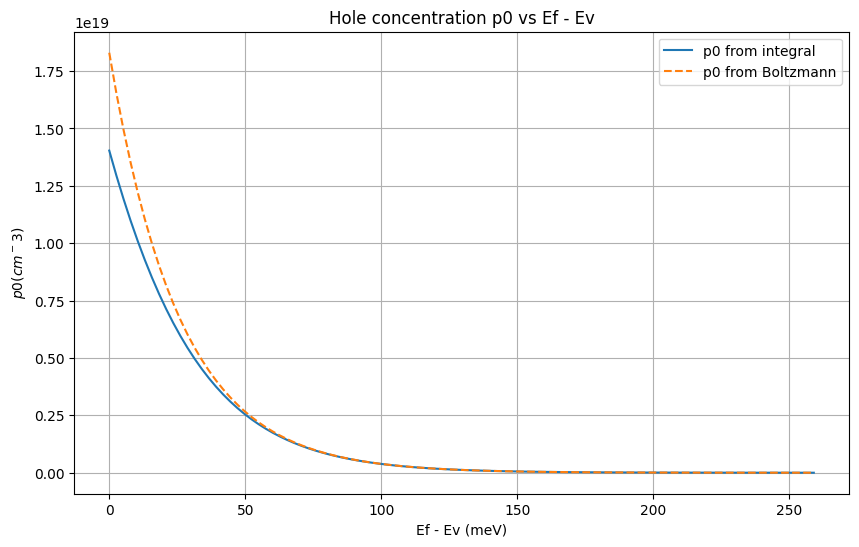

In [17]:
#check p0_integral against Boltzmann approximation
def p0_boltzmann(Ef_Ev_meV):    
    return Nv * np.exp(-Ef_Ev_meV / kT_meV)

# =========================
for i in range(1, 101):
    Ef_Ev_meV = 0.1*i * kT_meV
    p0_int = p0_integral(Ef_Ev_meV)
    p0_boltz = p0_boltzmann(Ef_Ev_meV)
    print(f"Ef - Ev = {Ef_Ev_meV:8.3f} meV, p0_integral = {p0_int:.4e}, p0_boltzmann = {p0_boltz:.4e}")

#plot p0 vs Ef - Ev
import matplotlib.pyplot as plt
Ef_Ev_range = np.linspace(0, 10 * kT_meV, 100)
p0_int_values = [p0_integral(Ef_Ev) for Ef_Ev in Ef_Ev_range]
p0_boltz_values = [p0_boltzmann(Ef_Ev) for Ef_Ev in Ef_Ev_range]    
plt.figure(figsize=(10, 6))
plt.plot(Ef_Ev_range, p0_int_values, label='p0 from integral')
plt.plot(Ef_Ev_range, p0_boltz_values, label='p0 from Boltzmann', linestyle='dashed')
plt.xlabel('Ef - Ev (meV)')
plt.ylabel('$p0 (cm^-3)$')
plt.title('Hole concentration p0 vs Ef - Ev')
plt.legend()
plt.grid()
plt.show()

## 用python root_scalar module迭代計算$E_f-E_v$

* 元件維持電中性︰$n_0+(N_a-p_a)=p_0+(N_d-n_d)=p_0\quad-(1)$
* hole concentration: $\quad p_0\quad integral \quad-(2)$
* holes in the acceptor energy state:
$$
p_a=\frac{N_a}{1+ge^{(\frac{E_f-E_a}{kT})}} \quad-(3)
$$
* 猜$E_f-E_a$計算(2)(3)直到滿足(1)
* 計算結果$E_f-E_v=27.122mev$
* Note:此時$E_f-E_a<0$

In [18]:




# =========================
# pa, n0, neutrality
# =========================

def calculate(Ef_Ea_meV):
    """
    Unknown variable:
        Ef_Ea_meV = Ef - Ea

    Ea - Ev = 44 meV
    Therefore:
        Ef - Ev = Ef - Ea + Ea - Ev
    """

    Ef_Ev_meV = Ef_Ea_meV + Ea_Ev_meV

    p0 = p0_integral(Ef_Ev_meV)

    pa = Na / (1 + g * np.exp(Ef_Ea_meV / kT_meV))

    n0 = n0p0_product / p0

    # neutrality:
    # n0 + (Na - pa) = p0
    error = n0 + (Na - pa) - p0

    return Ef_Ev_meV, p0, pa, n0, error


def neutrality_error(Ef_Ea_meV):
    return calculate(Ef_Ea_meV)[-1]


# =========================
# Scan
# =========================

print("Scan:")
for Ef_Ea in [-200, -150, -100, -75, -50, -25, 0, 25, 50]:
    Ef_Ev, p0, pa, n0, error = calculate(Ef_Ea)

    print(
        f"Ef-Ea = {Ef_Ea:8.3f} meV, "
        f"Ef-Ev = {Ef_Ev:8.3f} meV, "
        f"p0 = {p0:.4e}, "
        f"pa = {pa:.4e}, "
        f"Na-pa = {Na-pa:.4e}, "
        f"n0 = {n0:.4e}, "
        f"error = {error:.4e}"
    )


# =========================
# Find bracket automatically
# =========================

search_points = np.linspace(-300, 100, 161)

bracket = None
prev_x = search_points[0]
prev_f = neutrality_error(prev_x)

for x in search_points[1:]:
    fx = neutrality_error(x)

    if prev_f * fx < 0:
        bracket = [prev_x, x]
        break

    prev_x = x
    prev_f = fx


# =========================
# Solve
# =========================

if bracket is None:
    print("\nNo sign change found.")
    print("Try expanding the search range.")
else:
    print(f"\nBracket found: {bracket[0]:.3f} meV to {bracket[1]:.3f} meV")

    sol = root_scalar(
        neutrality_error,
        bracket=bracket,
        method="brentq",
        xtol=1e-8,
        rtol=1e-10
    )

    Ef_Ea_sol = sol.root
    Ef_Ev_sol, p0_sol, pa_sol, n0_sol, error_sol = calculate(Ef_Ea_sol)

    print("\nSolution:")
    print(f"converged = {sol.converged}")
    print(f"iterations = {sol.iterations}")
    print(f"Ef - Ea = {Ef_Ea_sol:.8f} meV")
    print(f"Ef - Ev = {Ef_Ev_sol:.8f} meV")
    print(f"p0 = {p0_sol:.6e} cm^-3")
    print(f"pa = {pa_sol:.6e} cm^-3")
    print(f"Na - pa = {Na - pa_sol:.6e} cm^-3")
    print(f"n0 = {n0_sol:.6e} cm^-3")
    print(f"left side  = n0 + (Na - pa) = {n0_sol + (Na - pa_sol):.6e}")
    print(f"right side = p0             = {p0_sol:.6e}")
    print(f"relative error = {error_sol / Na:.6e}")

Scan:
Ef-Ea = -200.000 meV, Ef-Ev = -156.000 meV, p0 = 2.1114e+20, pa = 4.9994e+19, Na-pa = 5.5365e+15, n0 = 4.0257e-01, error = -2.1114e+20
Ef-Ea = -150.000 meV, Ef-Ev = -106.000 meV, p0 = 1.2319e+20, pa = 4.9962e+19, Na-pa = 3.8138e+16, n0 = 6.8998e-01, error = -1.2315e+20
Ef-Ea = -100.000 meV, Ef-Ev =  -56.000 meV, p0 = 5.6256e+19, pa = 4.9738e+19, Na-pa = 2.6171e+17, n0 = 1.5109e+00, error = -5.5994e+19
Ef-Ea =  -75.000 meV, Ef-Ev =  -31.000 meV, p0 = 3.2773e+19, pa = 4.9319e+19, Na-pa = 6.8131e+17, n0 = 2.5936e+00, error = -3.2092e+19
Ef-Ea =  -50.000 meV, Ef-Ev =   -6.000 meV, p0 = 1.6798e+19, pa = 4.8250e+19, Na-pa = 1.7500e+18, n0 = 5.0600e+00, error = -1.5048e+19
Ef-Ea =  -25.000 meV, Ef-Ev =   19.000 meV, p0 = 7.6130e+18, pa = 4.5653e+19, Na-pa = 4.3472e+18, n0 = 1.1165e+01, error = -3.2659e+18
Ef-Ea =    0.000 meV, Ef-Ev =   44.000 meV, p0 = 3.1575e+18, pa = 4.0000e+19, Na-pa = 1.0000e+19, n0 = 2.6920e+01, error = 6.8425e+18
Ef-Ea =   25.000 meV, Ef-Ev =   69.000 meV, p0 = 1

# 只fit $\alpha, \beta, \gamma$

* 先假設簡單情況用簡單方法找出大致實驗參數
* 假設uniform polarization且$P_x=P_y=0, 即P=P_z$
* 假設實驗量測的是$Q_g=-Q_s \approx |P_z|$，假設沒漏電（已剔除漏電嚴重量測結果）
* 以下用$P代替Q_g$

## Math aspect


* 假設uniform polarization且 $P_x=P_y=0,P=P_z且steady \quad state$

* $free \quad energy \quad density=f=f_{Landau}+f_{electric}=\frac{1}{2}\alpha P^2+\frac{1}{4}\beta P^4+\frac{1}{6}\gamma P^6-EP$

* $TDGL \quad eq =>\frac{df}{dP}=\alpha P+\beta P^3+\gamma P^5-E=\frac{-1}{\Gamma}\frac{dP}{dt}=0\\$

* $E=\frac{V_{fe}}{t_{fe}}=\alpha P+\beta P^3+\gamma P^5\\$

* $Let \quad V_{fe}=t_{fe}P(\alpha +\beta P^2+\gamma P^4)=0\\$

* $Let \quad P^2=k,\quad t_{fe}P(\alpha +\beta k+\gamma k^2)=0\\$

* $公式解︰k=\frac{-\beta \pm \sqrt{\beta^2+4|\gamma||\alpha|}}{2 \gamma}\qquad \alpha 是負的for鐵電 \quad \gamma 是正的因為慣例極化向下為正\\$

* $P=\pm \sqrt{\frac{-\beta \pm \sqrt{\beta^2+4|\gamma||\alpha|}}{2 \gamma}}$

* $P_{\pm,-}不存在$

* $P_{\pm,+}=\pm \sqrt{\frac{-\beta + \sqrt{\beta^2+4|\gamma||\alpha|}}{2 |\gamma|}}$

* **調小|$\gamma$|或調大|$\alpha$|撐開PV loop**

## 使用者參數設置

In [120]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import brentq, least_squares


# ============================================================
# 1. User settings
# ============================================================

CSV_PATH = "/home/kaiwi/FAM/Dataset/MFIS_t_8.csv"
CSV_PATHf = "/home/kaiwi/FAM/Dataset/MFIS_t_8_tf.csv"

# 你的 CSV 欄位名稱
#VG_COL = "Vg"
#P_COL = "P"

# 如果你的 P 單位是 uC/cm^2，設成 True
# 1 uC/cm^2 = 0.01 C/m^2
P_IS_UC_PER_CM2 = True

# Device parameters
Vfb = -0.5429

tFE = 8e-9      # FE thickness, meter
tIL = 1.5e-9     # IL thickness, meter, 自己改

eps0 = 8.8541878128e-12
eps_si_rel = 11.7
eps_s = eps_si_rel * eps0

eps_IL_rel = 3.9

# Temperature
T = 300.0
q = 1.602176634e-19
kB = 1.380649e-23

# beta_th = q / kT, unit: 1/V
# 注意：這不是 Landau beta
beta_th = q / (kB * T)

# Semiconductor carrier concentrations, unit: m^-3
# 這裡一定要改成你的值
n0p0_product = 8.5e31

p0 = 5.763664e+24 #
n0 = n0p0_product / p0

# root finding range for phi_s
PHI_MIN_INIT = -2.0
PHI_MAX_INIT = 2.0

# 是否使用 robust loss
# 一開始建議 "linear"，如果資料有 outlier 可改 "soft_l1"
LOSS_TYPE = "linear"
# LOSS_TYPE = "soft_l1"

## Load Data

In [121]:
# ============================================================
# 2. Load data
# ============================================================

df = pd.read_csv(CSV_PATH, header=None)

# 第 0 欄：Vg
# 第 1 欄：P
Vg_exp = df.iloc[:, 0].to_numpy(dtype=float)
P_raw = df.iloc[:, 1].to_numpy(dtype=float)

if P_IS_UC_PER_CM2:
    P_exp = P_raw * 0.01      # uC/cm^2 -> C/m^2
else:
    P_exp = P_raw.copy()

dff = pd.read_csv(CSV_PATHf, header=None)

Vg_exptf = dff.iloc[:, 0].to_numpy(dtype=float)
P_rawtf = dff.iloc[:, 1].to_numpy(dtype=float)

if P_IS_UC_PER_CM2:
    P_exptf = P_rawtf * 0.01      # uC/cm^2 -> C/m^2
else:
    P_exptf = P_rawtf.copy()


## 計算Qs

In [122]:
# ============================================================
# 3. MOS surface charge model
# ============================================================

def Qs_magnitude(phi_s):
    """
    Return |Qs(phi_s)| in C/m^2.

    Qs expression:
    sqrt( 2 eps_s q / beta_th *
          [ p0(exp(-beta_th phi_s)+beta_th phi_s-1)
          + n0(exp(beta_th phi_s)-beta_th phi_s-1) ] )
    """

    x = beta_th * phi_s

    # 防止 exp overflow
    x = np.clip(x, -100, 100)

    term_p = p0 * (np.exp(-x) + x - 1.0)
    term_n = n0 * (np.exp(x) - x - 1.0)

    inside = (2.0 * eps_s * q / beta_th) * (term_p + term_n)

    # 避免數值誤差導致小負數
    inside = np.maximum(inside, 0.0)

    return np.sqrt(inside)


def Qs_signed(phi_s):
    """
    Signed semiconductor charge.

    對常見 p-type substrate:
    phi_s > 0 時，depletion/inversion，Qs < 0
    phi_s < 0 時，accumulation，Qs > 0

    所以使用：
        Qs = -sign(phi_s) * |Qs|
    """

    if np.isscalar(phi_s):
        if abs(phi_s) < 1e-15:
            return 0.0
        return -np.sign(phi_s) * Qs_magnitude(phi_s)

    phi_s = np.asarray(phi_s)
    return -np.sign(phi_s) * Qs_magnitude(phi_s)


def solve_phi_s_from_P(P):
    """
    Solve Qs(phi_s) + P = 0.

    因為 -P ≈ Qs，所以 Qs + P = 0.
    """

    if abs(P) < 1e-12:
        return 0.0

    def f(phi):
        return Qs_signed(phi) + P

    # 根據 P 的正負決定 bracket 方向
    # P > 0 -> Qs = -P < 0 -> phi_s > 0
    # P < 0 -> Qs = -P > 0 -> phi_s < 0
    if P > 0:
        a, b = 0.0, PHI_MAX_INIT
    else:
        a, b = PHI_MIN_INIT, 0.0

    fa = f(a)
    fb = f(b)

    # 如果 bracket 不夠大，自動放大
    expand_count = 0
    while fa * fb > 0 and expand_count < 20:
        expand_count += 1

        if P > 0:
            b *= 2.0
            fb = f(b)
        else:
            a *= 2.0
            fa = f(a)

    if fa * fb > 0:
        raise RuntimeError(
            f"Cannot bracket phi_s root for P = {P:.4e} C/m^2. "
            f"Try increasing PHI range or check p0/n0/P units."
        )

    return brentq(f, a, b, xtol=1e-12, rtol=1e-10, maxiter=200)

### 驗證

* 結果和細奈米有99.87%像

In [93]:
P_values = np.linspace(-0.008, 0.008, 10001)  # 含端點
phi_s_t = np.array([solve_phi_s_from_P(P) for P in P_values])


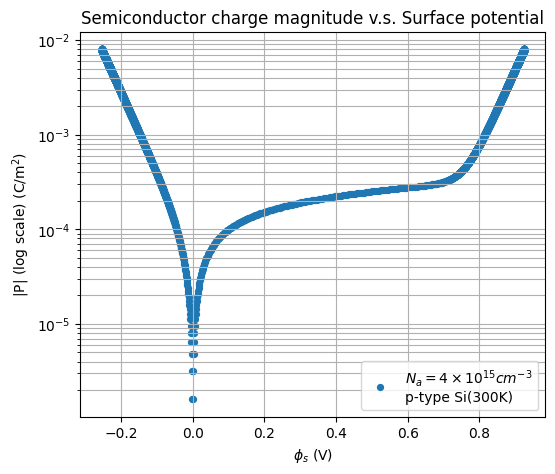

In [119]:
P_abs = np.abs(P_values)
mask = P_abs > 0  # 避免 log10(0)

plt.figure(figsize=(6, 5))
plt.scatter(phi_s_t[mask], P_abs[mask], s=18, label=r"$N_a=4\times10^{15}cm^{-3}$"+"\n"+r"p-type Si(300K)")
plt.yscale("log")
plt.title("Semiconductor charge magnitude v.s. Surface potential")
plt.xlabel(r"$\phi_s$ (V)")
plt.ylabel("|P| (log scale) (C/m$^2$)")
plt.grid(True, which="both")
plt.legend()

In [185]:
# ============================================================
# 6. Landau model
# ============================================================
def VFE_landau(P, alpha, beta_L, gamma,Pimp=0, Vimp=0):
    return tFE * (alpha * (P+Pimp) + beta_L * (P+Pimp)**3 + gamma * (P+Pimp)**5) + Vimp


def residual_landau(params, P, VFE_target, weights=None):
    alpha, beta_L, gamma = params

    VFE_fit = VFE_landau(P, alpha, beta_L, gamma)

    r = VFE_fit - VFE_target

    if weights is not None:
        r = r * weights

    return r



In [181]:
P_plot = P_exp /0.01  # C/m^2 -> uC/cm^2
P_plottf = P_exptf /0.01  # C/m^2 -> uC/cm^2
N = len(Vg_exp)



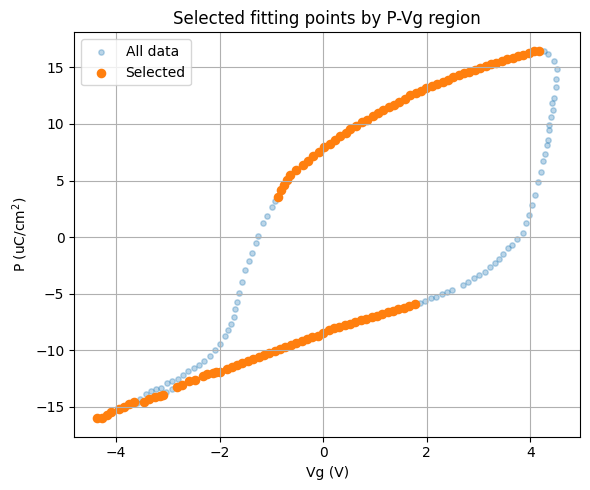

In [182]:
plt.figure(figsize=(6, 5))

plt.scatter(Vg_exp, P_plot, s=15, alpha=0.3, label="All data")
plt.scatter(Vg_exptf, P_plottf, s=35, label="Selected")


plt.xlabel("Vg (V)")
plt.ylabel("P (uC/cm$^2$)")
plt.title("Selected fitting points by P-Vg region")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## main

In [183]:

# ============================================================
# 4. Compute phi_s and experimental VFE
# ============================================================

phi_s_exptf = np.array([solve_phi_s_from_P(P) for P in P_exptf])
phi_s_exp = np.array([solve_phi_s_from_P(P) for P in P_exp]) 

# Qs ≈ -P
Qs_exptf = -P_exptf
Qs_exp = -P_exp

# VIL = -Qs * tIL / (eps_IL_rel * eps0)
# since Qs = -P, VIL = P * tIL / (eps_IL_rel * eps0)
VIL_exptf = -Qs_exptf * tIL / (eps_IL_rel * eps0)
VIL_exp = -Qs_exp * tIL / (eps_IL_rel * eps0)

VFE_exptf = Vg_exptf - Vfb - VIL_exptf - phi_s_exptf
VFE_exp = Vg_exp - Vfb - VIL_exp - phi_s_exp


In [187]:
# ============================================================
# 7. Fitting alpha, beta, gamma
# ============================================================

# 初始值很重要。這組只是 generic guess，通常你要依材料調整。
# alpha 單位約 m/F
# beta  單位 m^5/(C^2 F)
# gamma 單位 m^9/(C^4 F)
x0 = np.array([
    -4.330846e+06,   # alpha
     8.890780e+06,  # beta_L
     03.871486e+06  # gamma
           # Vimp
], dtype=float)

# 如果想限制物理符號，可以打開 bounds
# 典型 sixth-order FE:
# alpha < 0, beta 可以正或負，gamma > 0
bounds_lower = np.array([-np.inf, -np.inf, 0.0])
bounds_upper = np.array([0.0, np.inf, np.inf])

# branch 權重，先全部設成 1
weights = np.ones_like(P_exptf)

# 你也可以讓 up/down branch 權重相同，避免某一段點數比較多
# 例如：
# weights[up_mask] = 1.0 / np.sqrt(np.sum(up_mask))
# weights[down_mask] = 1.0 / np.sqrt(np.sum(down_mask))

result = least_squares(
    residual_landau,
    x0=x0,
    bounds=(bounds_lower, bounds_upper),
    args=(P_exptf, -VFE_exptf, weights),
    loss="soft_l1",
    f_scale=0.2,
    max_nfev=50000,
    verbose=1
)

alpha_fit, beta_fit, gamma_fit = result.x
print("\n===== Fit result =====")
print(f"alpha = {alpha_fit:.6e}")
print(f"beta  = {beta_fit:.6e}")
print(f"gamma = {gamma_fit:.6e}")
#print(f"Pimp  = {Pimp_fit:.6e} C/m^2")
#print(f"Vimp  = {Vimp_fit:.6e} V")

print("\n===== Optimization info =====")
print("success:", result.success)
print("message:", result.message)
print("cost:", result.cost)

VFE_fit = VFE_landau(P_exptf, alpha_fit, beta_fit, gamma_fit)

rmse_VFE = np.sqrt(np.mean((VFE_fit - VFE_exptf)**2))
print(f"\nVFE RMSE = {rmse_VFE:.6e} V")


# ============================================================
# 8. Convert fitted VFE back to Vg
# ============================================================

Vg_fit = Vfb + VFE_fit + VIL_exptf + phi_s_exptf

rmse_Vg = np.sqrt(np.mean((Vg_fit - Vg_exptf)**2))
print(f"Vg RMSE = {rmse_Vg:.6e} V")

`gtol` termination condition is satisfied.
Function evaluations 3, initial cost 8.5681e+01, final cost 8.5589e+01, first-order optimality 2.99e-10.

===== Fit result =====
alpha = -2.748887e-06
beta  = 3.797707e+07
gamma = 4.416806e+06

===== Optimization info =====
success: True
message: `gtol` termination condition is satisfied.
cost: 85.58851388508845

VFE RMSE = 4.143627e+00 V
Vg RMSE = 4.143627e+00 V


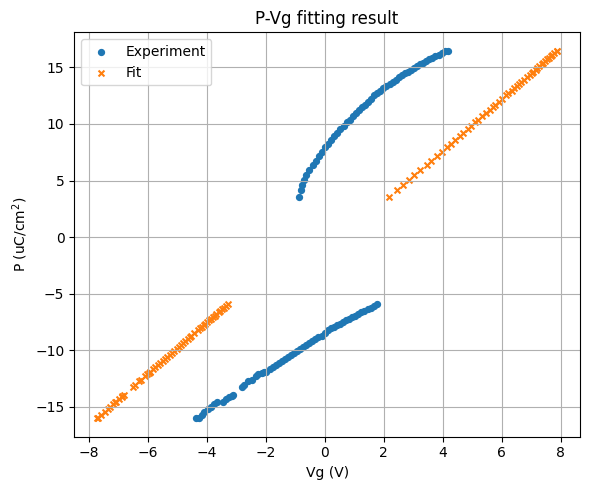

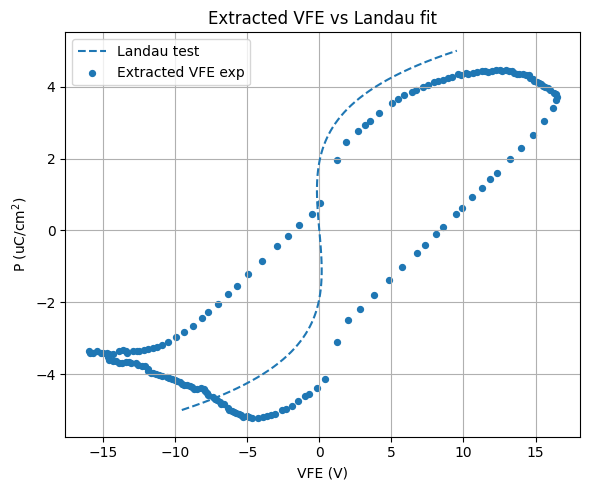

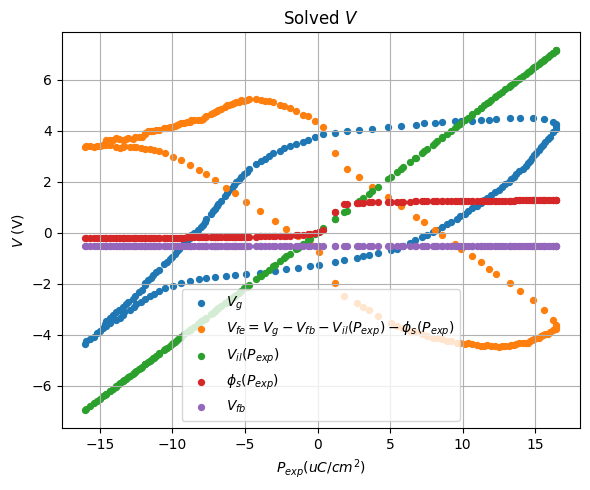

In [234]:

# ============================================================
# 9. Plot results
# ============================================================

plt.figure(figsize=(6, 5))
plt.scatter(Vg_exptf, P_exptf / 0.01, s=18, label="Experiment")
plt.scatter(Vg_fit, P_exptf / 0.01, s=18, label="Fit", marker="x")
plt.xlabel("Vg (V)")
plt.ylabel("P (uC/cm$^2$)")
plt.title("P-Vg fitting result")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


plt.figure(figsize=(6, 5))
x = np.linspace(-5, 5, 100)
y = VFE_landau(x, alpha_fit, beta_fit, gamma_fit)
y_t = VFE_landau(x, -2.748887e+07, 7.097707e+06, 1.416806e5)
#plt.plot(y, x, label="Landau fit curve")
plt.plot(y_t, x, label="Landau test", linestyle="dashed")
plt.scatter(P_exp / 0.01, -VFE_exp, s=18, label="Extracted VFE exp")
#plt.scatter(VFE_fit, P_exptf / 0.01, s=18, label="Landau fit", marker="x")
plt.xlabel("VFE (V)")
plt.ylabel("P (uC/cm$^2$)")
plt.title("Extracted VFE vs Landau fit")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()




plt.figure(figsize=(6, 5))
Vfb_plot = Vfb * np.ones_like(P_exp)
Vg_add = Vfb_plot+VFE_exp+VIL_exp+phi_s_exp
plt.scatter(P_exp / 0.01, Vg_exp, s=18, label=r"$V_g$")
plt.scatter(P_exp / 0.01, VFE_exp, s=18, label=r"$V_{fe}=V_g-V_{fb}-V_{il}(P_{exp})-\phi_s(P_{exp})$")
plt.scatter(P_exp / 0.01, VIL_exp, s=18, label=r"$V_{il}(P_{exp})$")
plt.scatter(P_exp / 0.01, phi_s_exp, s=18, label=r"$\phi_s(P_{exp})$")
plt.scatter(P_exp / 0.01, Vfb_plot, s=18, label=r"$V_{fb}$")
#plt.scatter(P_exp / 0.01, Vg_add, s=18, label=r"$V_g=V_{fb}+V_{fe}+V_{il}+\phi_s$")

plt.xlabel(r"$P_{exp} (uC/cm^2)$")
plt.ylabel(r"$V$ (V)")
plt.title(r"Solved $V$")
plt.grid(True)
plt.tight_layout()
plt.legend()
plt.show()

In [173]:
print("P uC/cm2:", P_plot.min(), P_plot.max())
print("phi_s:", phi_s_exp.min(), phi_s_exp.max())
print("VIL:", VIL_exp.min(), VIL_exp.max())
print("VFE_exp:", VFE_exp.min(), VFE_exp.max())

P uC/cm2: -16.001802920359246 16.460412243959578
phi_s: -0.22113299370402945 1.2695059443435563
VIL: -6.950992812526841 7.150207246548388
VFE_exp: -4.469821223628095 5.231083925139834
